In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']  = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ All Libraries Loaded!")
print("🏠 House Price Prediction — Advanced Model Ready!")

✅ All Libraries Loaded!
🏠 House Price Prediction — Advanced Model Ready!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

ZIP = '/content/drive/MyDrive/ProdigyInternshipdatasets/housepricesreg.zip'

with zipfile.ZipFile(ZIP, 'r') as z:
    z.extractall('/content/task1/')

print("✅ Extracted!")
print(f"📁 Files: {os.listdir('/content/task1/')}")

df = pd.read_csv('/content/task1/train.csv')
print(f"\n📦 Dataset Loaded!")
print(f"🏠 Total Houses : {df.shape[0]}")
print(f"📋 Total Columns: {df.shape[1]}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Extracted!
📁 Files: ['data_description.txt', 'sample_submission.csv', 'train.csv', 'test.csv']

📦 Dataset Loaded!
🏠 Total Houses : 1460
📋 Total Columns: 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'SalePrice']

df_num = df[num_cols + ['SalePrice']].copy()

for col in df_num.columns:
    df_num[col].fillna(df_num[col].median(), inplace=True)

corr_with_price = df_num.corr()['SalePrice'].abs().sort_values(ascending=False)
TOP_FEATURES    = corr_with_price[1:16].index.tolist()

data = df_num[TOP_FEATURES + ['SalePrice']].copy()

print("=" * 50)
print("✅ Features Selected & Data Cleaned!")
print("=" * 50)
print(f"🏠 Total Houses  : {len(data)}")
print(f"🔢 Features Used : {len(TOP_FEATURES)}")
print("=" * 50)
print("\n📌 Top Features by Correlation:")
for i, feat in enumerate(TOP_FEATURES):
    print(f"  {i+1:02d}. {feat:<25} {corr_with_price[feat]:.3f}")

✅ Features Selected & Data Cleaned!
🏠 Total Houses  : 1460
🔢 Features Used : 15

📌 Top Features by Correlation:
  01. OverallQual               0.791
  02. GrLivArea                 0.709
  03. GarageCars                0.640
  04. GarageArea                0.623
  05. TotalBsmtSF               0.614
  06. 1stFlrSF                  0.606
  07. FullBath                  0.561
  08. TotRmsAbvGrd              0.534
  09. YearBuilt                 0.523
  10. YearRemodAdd              0.507
  11. MasVnrArea                0.473
  12. Fireplaces                0.467
  13. GarageYrBlt               0.467
  14. BsmtFinSF1                0.386
  15. LotFrontage               0.335


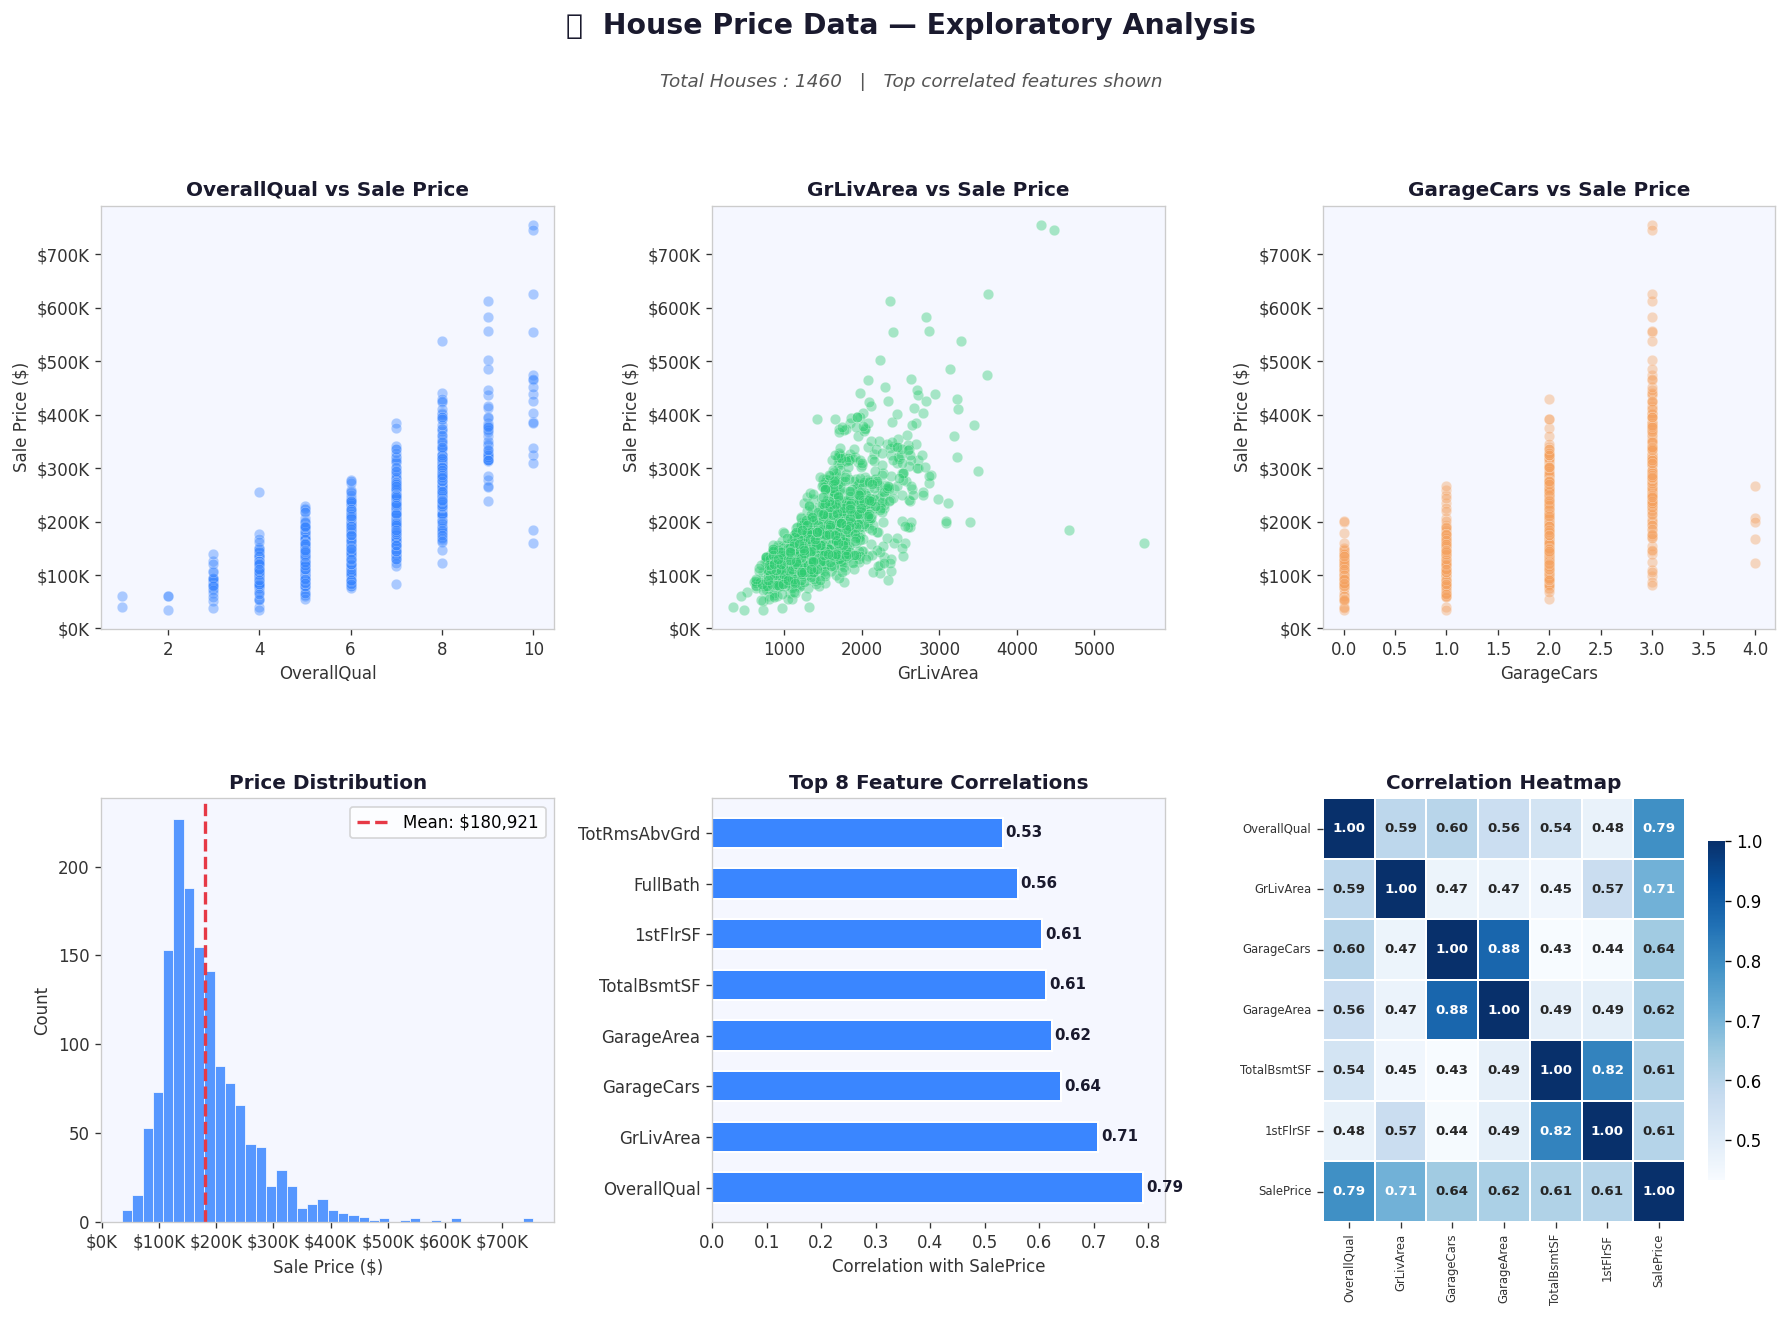

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.patch.set_facecolor('white')
fig.text(0.5, 1.01, '🏠  House Price Data — Exploratory Analysis',
         ha='center', fontsize=17, fontweight='bold', color='#1a1a2e')
fig.text(0.5, 0.97, f'Total Houses : {len(data)}   |   Top correlated features shown',
         ha='center', fontsize=11, color='#555555', style='italic')

top3 = TOP_FEATURES[:3]
plot_colors = ['#3a86ff', '#2ecc71', '#f4a261']

for i, (feat, col) in enumerate(zip(top3, plot_colors)):
    axes[0, i].set_facecolor('#f5f7ff')
    axes[0, i].scatter(data[feat], data['SalePrice'],
                       alpha=0.4, color=col,
                       edgecolors='white', linewidth=0.3, s=40)
    axes[0, i].set_title(f'{feat} vs Sale Price',
                          fontweight='bold', color='#1a1a2e', fontsize=12)
    axes[0, i].set_xlabel(feat, color='#333333')
    axes[0, i].set_ylabel('Sale Price ($)', color='#333333')
    axes[0, i].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    axes[0, i].tick_params(colors='#333333')
    for s in axes[0, i].spines.values():
        s.set_color('#cccccc')

axes[1, 0].set_facecolor('#f5f7ff')
axes[1, 0].hist(data['SalePrice'], bins=40, color='#3a86ff',
                edgecolor='white', linewidth=0.5, alpha=0.85)
axes[1, 0].axvline(data['SalePrice'].mean(), color='#e63946',
                   linestyle='--', linewidth=2,
                   label=f"Mean: ${data['SalePrice'].mean():,.0f}")
axes[1, 0].set_title('Price Distribution', fontweight='bold',
                      color='#1a1a2e', fontsize=12)
axes[1, 0].set_xlabel('Sale Price ($)', color='#333333')
axes[1, 0].set_ylabel('Count', color='#333333')
axes[1, 0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1, 0].legend(facecolor='white', edgecolor='#cccccc')
axes[1, 0].tick_params(colors='#333333')
for s in axes[1, 0].spines.values():
    s.set_color('#cccccc')

axes[1, 1].set_facecolor('#f5f7ff')
top8_corr = corr_with_price[1:9]
bars = axes[1, 1].barh(top8_corr.index, top8_corr.values,
                        color='#3a86ff', edgecolor='white',
                        linewidth=1.2, height=0.6)
axes[1, 1].set_title('Top 8 Feature Correlations',
                      fontweight='bold', color='#1a1a2e', fontsize=12)
axes[1, 1].set_xlabel('Correlation with SalePrice', color='#333333')
axes[1, 1].tick_params(colors='#333333')
for bar, val in zip(bars, top8_corr.values):
    axes[1, 1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                    f'{val:.2f}', va='center',
                    fontweight='bold', fontsize=9, color='#1a1a2e')
for s in axes[1, 1].spines.values():
    s.set_color('#cccccc')

axes[1, 2].set_facecolor('#f5f7ff')
corr_matrix = data[TOP_FEATURES[:6] + ['SalePrice']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues',
            linewidths=1, linecolor='white',
            annot_kws={'size': 8, 'weight': 'bold'},
            ax=axes[1, 2], cbar_kws={'shrink': 0.8})
axes[1, 2].set_title('Correlation Heatmap',
                      fontweight='bold', color='#1a1a2e', fontsize=12)
axes[1, 2].tick_params(colors='#333333', labelsize=7)

plt.subplots_adjust(wspace=0.35, hspace=0.4)
plt.show()

In [5]:
X = data[TOP_FEATURES]
y = data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=" * 50)
print("📂 Data Split Done!")
print("=" * 50)
print(f"🏋️  Training Houses : {len(X_train)}")
print(f"🧪 Testing Houses  : {len(X_test)}")
print(f"🔢 Features Used   : {len(TOP_FEATURES)}")
print("=" * 50)
print("\n🌲 Training Random Forest...")
print("⏳ Please wait 1-2 minutes...")
print("─" * 42)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

r2_rf   = r2_score(y_test, y_pred_rf)
r2_gb   = r2_score(y_test, y_pred_gb)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

if r2_rf >= r2_gb:
    best_model = rf_model
    y_pred     = y_pred_rf
    r2         = r2_rf
    rmse       = rmse_rf
    model_name = "Random Forest"
else:
    best_model = gb_model
    y_pred     = y_pred_gb
    r2         = r2_gb
    rmse       = rmse_gb
    model_name = "Gradient Boosting"

print("─" * 42)
print(f"🌲 Random Forest R²      : {r2_rf*100:.2f}%")
print(f"🚀 Gradient Boosting R²  : {r2_gb*100:.2f}%")
print(f"\n🏆 Best Model            : {model_name}")
print(f"✅ Best R² Score         : {r2*100:.2f}%")

📂 Data Split Done!
🏋️  Training Houses : 1168
🧪 Testing Houses  : 292
🔢 Features Used   : 15

🌲 Training Random Forest...
⏳ Please wait 1-2 minutes...
──────────────────────────────────────────
──────────────────────────────────────────
🌲 Random Forest R²      : 87.93%
🚀 Gradient Boosting R²  : 87.44%

🏆 Best Model            : Random Forest
✅ Best R² Score         : 87.93%


📊  MODEL PERFORMANCE REPORT
  🏆 Best Model  : Random Forest
  ✅ R² Score    : 0.8793   🟢 Excellent!
  📉 RMSE        : $30,423.35
  📉 MSE         : $925,580,144.91

  R² means model explains 87.9% of price variation!

  Accuracy : [██████████████████████████░░░░] 87.9%


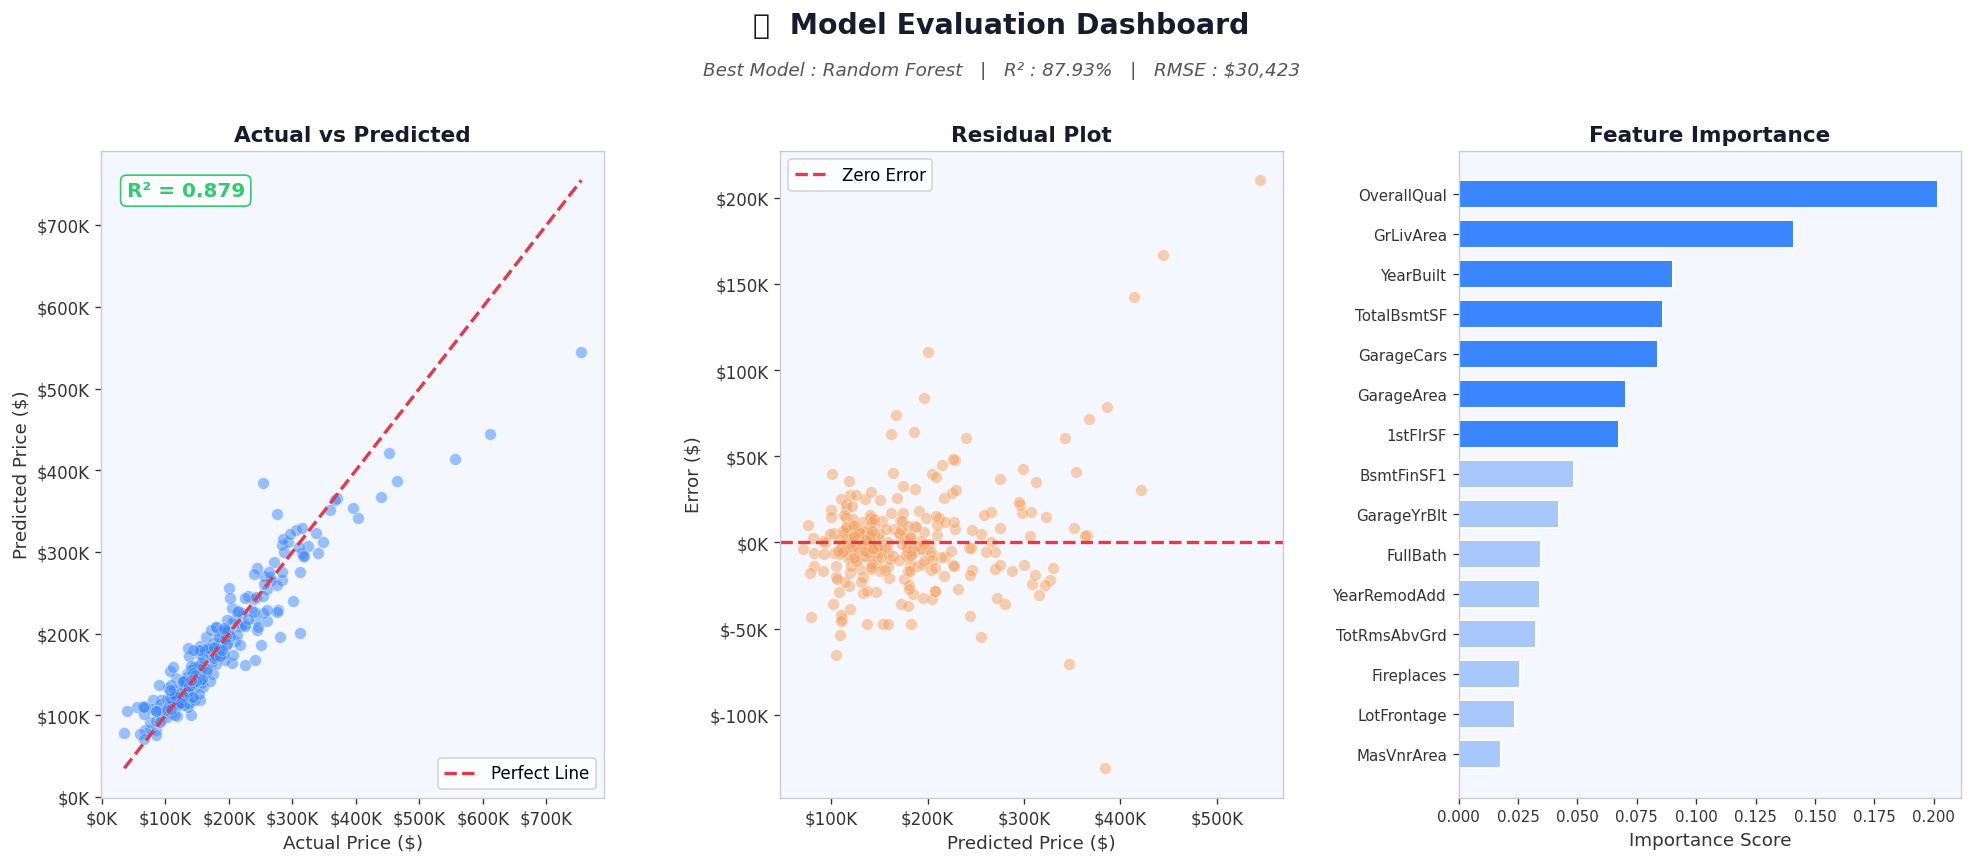

In [6]:
print("=" * 50)
print("📊  MODEL PERFORMANCE REPORT")
print("=" * 50)
print(f"  🏆 Best Model  : {model_name}")
print(f"  ✅ R² Score    : {r2:.4f}   {'🟢 Excellent!' if r2>0.85 else '🟡 Good'}")
print(f"  📉 RMSE        : ${rmse:,.2f}")
print(f"  📉 MSE         : ${rmse**2:,.2f}")
print("=" * 50)
print(f"\n  R² means model explains {r2*100:.1f}% of price variation!")
bar = int(r2 * 30)
print(f"\n  Accuracy : [{'█'*bar}{'░'*(30-bar)}] {r2*100:.1f}%")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('white')
fig.text(0.5, 1.02, '📊  Model Evaluation Dashboard',
         ha='center', fontsize=17, fontweight='bold', color='#1a1a2e')
fig.text(0.5, 0.97,
         f'Best Model : {model_name}   |   R² : {r2*100:.2f}%   |   RMSE : ${rmse:,.0f}',
         ha='center', fontsize=11, color='#555555', style='italic')

axes[0].set_facecolor('#f5f7ff')
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#3a86ff',
                edgecolors='white', linewidth=0.4, s=50)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#e63946', linewidth=2,
             linestyle='--', label='Perfect Line')
axes[0].set_title('Actual vs Predicted', fontweight='bold',
                  color='#1a1a2e', fontsize=13)
axes[0].set_xlabel('Actual Price ($)',    color='#333333', fontsize=11)
axes[0].set_ylabel('Predicted Price ($)', color='#333333', fontsize=11)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].legend(facecolor='white', edgecolor='#cccccc')
axes[0].text(0.05, 0.93, f'R² = {r2:.3f}',
             transform=axes[0].transAxes,
             fontsize=12, color='#2ecc71', fontweight='bold',
             bbox=dict(facecolor='white', edgecolor='#2ecc71',
                       boxstyle='round,pad=0.3'))
axes[0].tick_params(colors='#333333')
for s in axes[0].spines.values():
    s.set_color('#cccccc')

residuals = y_test.values - y_pred
axes[1].set_facecolor('#f5f7ff')
axes[1].scatter(y_pred, residuals, alpha=0.5, color='#f4a261',
                edgecolors='white', linewidth=0.4, s=50)
axes[1].axhline(0, color='#e63946', linewidth=2,
                linestyle='--', label='Zero Error')
axes[1].set_title('Residual Plot', fontweight='bold',
                  color='#1a1a2e', fontsize=13)
axes[1].set_xlabel('Predicted Price ($)', color='#333333', fontsize=11)
axes[1].set_ylabel('Error ($)',           color='#333333', fontsize=11)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].legend(facecolor='white', edgecolor='#cccccc')
axes[1].tick_params(colors='#333333')
for s in axes[1].spines.values():
    s.set_color('#cccccc')

feat_imp = pd.Series(best_model.feature_importances_,
                     index=TOP_FEATURES).sort_values(ascending=True)
feat_colors = ['#3a86ff' if v > feat_imp.median() else '#a8c7fa'
               for v in feat_imp.values]
axes[2].set_facecolor('#f5f7ff')
axes[2].barh(feat_imp.index, feat_imp.values,
             color=feat_colors, edgecolor='white',
             linewidth=1.2, height=0.7)
axes[2].set_title('Feature Importance', fontweight='bold',
                  color='#1a1a2e', fontsize=13)
axes[2].set_xlabel('Importance Score', color='#333333', fontsize=11)
axes[2].tick_params(colors='#333333', labelsize=9)
for s in axes[2].spines.values():
    s.set_color('#cccccc')

plt.subplots_adjust(wspace=0.35)
plt.show()

🏠  HOUSE PRICE PREDICTOR
Type           Size   Quality   Predicted Price
────────────────────────────────────────────────────
Small         800sqft       4/10   $       120,878
Medium       1500sqft       5/10   $       158,389
Large        2500sqft       7/10   $       231,472
XL           3500sqft       8/10   $       301,130
Luxury       5000sqft      10/10   $       346,924


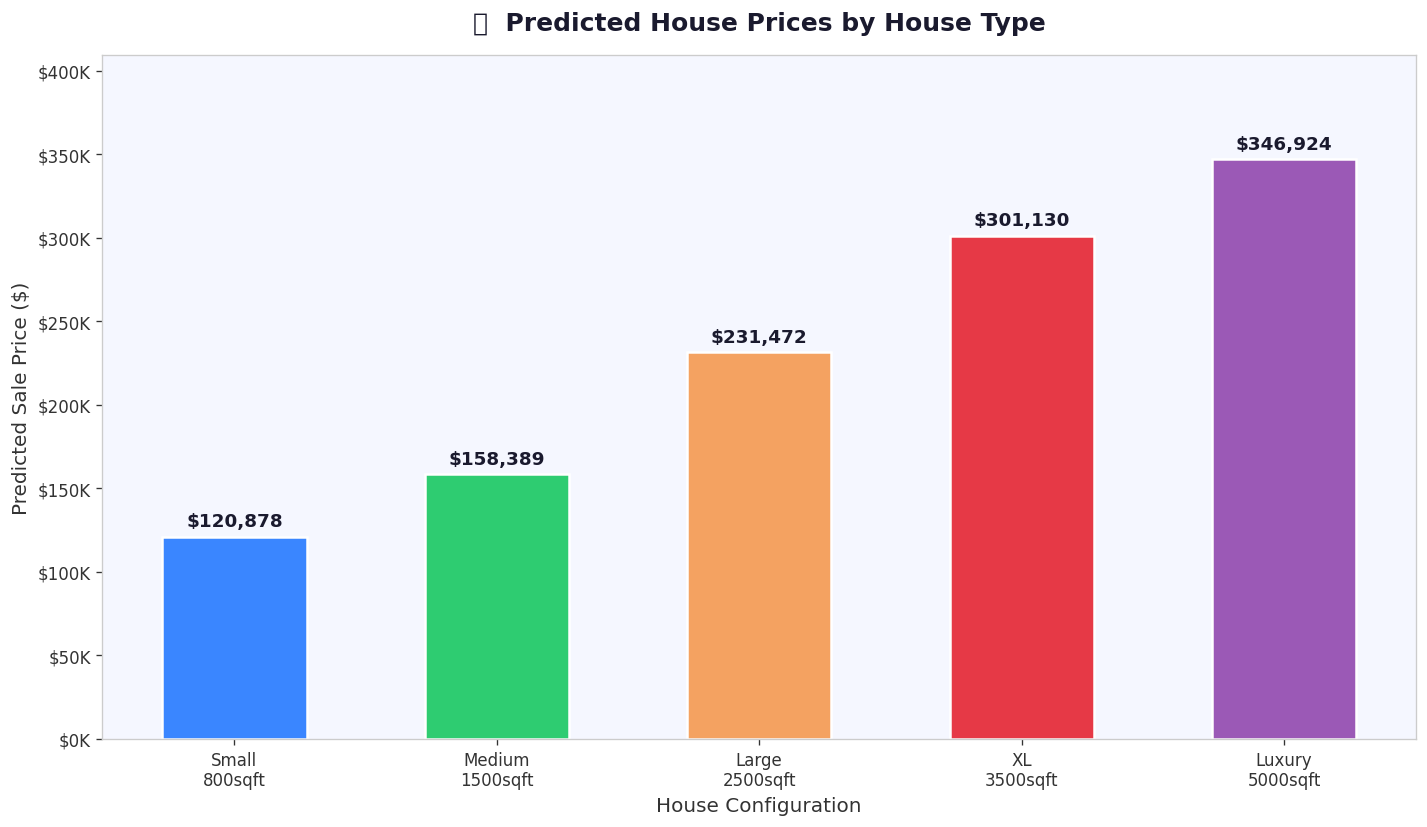

In [7]:
test_houses = pd.DataFrame({
    'House' : ['Small', 'Medium', 'Large', 'XL', 'Luxury'],
})

sample_inputs = pd.DataFrame(
    np.zeros((5, len(TOP_FEATURES))),
    columns=TOP_FEATURES
)

if 'GrLivArea'    in TOP_FEATURES: sample_inputs['GrLivArea']    = [800, 1500, 2500, 3500, 5000]
if 'OverallQual'  in TOP_FEATURES: sample_inputs['OverallQual']  = [4, 5, 7, 8, 10]
if 'GarageCars'   in TOP_FEATURES: sample_inputs['GarageCars']   = [0, 1, 2, 3, 3]
if 'TotalBsmtSF'  in TOP_FEATURES: sample_inputs['TotalBsmtSF']  = [400, 800, 1200, 1600, 2000]
if 'FullBath'     in TOP_FEATURES: sample_inputs['FullBath']     = [1, 1, 2, 2, 3]
if 'YearBuilt'    in TOP_FEATURES: sample_inputs['YearBuilt']    = [1970, 1990, 2000, 2010, 2020]
if 'BedroomAbvGr' in TOP_FEATURES: sample_inputs['BedroomAbvGr'] = [2, 3, 3, 4, 5]

for col in TOP_FEATURES:
    if sample_inputs[col].sum() == 0:
        sample_inputs[col] = data[col].median()

predictions = best_model.predict(sample_inputs)

print("=" * 52)
print("🏠  HOUSE PRICE PREDICTOR")
print("=" * 52)
print(f"{'Type':<10} {'Size':>8} {'Quality':>9} {'Predicted Price':>17}")
print("─" * 52)
house_types = ['Small', 'Medium', 'Large', 'XL', 'Luxury']
sizes       = [800, 1500, 2500, 3500, 5000]
quals       = [4, 5, 7, 8, 10]
for i in range(5):
    print(f"{house_types[i]:<10} {sizes[i]:>6}sqft {quals[i]:>7}/10   ${predictions[i]:>14,.0f}")

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f5f7ff')

bar_colors = ['#3a86ff','#2ecc71','#f4a261','#e63946','#9b59b6']
labels     = [f"{t}\n{s}sqft" for t, s in zip(house_types, sizes)]
bars       = ax.bar(labels, predictions, color=bar_colors,
                    edgecolor='white', linewidth=1.5, width=0.55)

for bar, price in zip(bars, predictions):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 4000,
            f'${price:,.0f}',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#1a1a2e')

ax.set_title('🏠  Predicted House Prices by House Type',
             fontsize=15, fontweight='bold', color='#1a1a2e', pad=15)
ax.set_xlabel('House Configuration', fontsize=12, color='#333333')
ax.set_ylabel('Predicted Sale Price ($)', fontsize=12, color='#333333')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_ylim(0, max(predictions) * 1.18)
ax.tick_params(colors='#333333')
for s in ax.spines.values():
    s.set_color('#cccccc')

plt.tight_layout()
plt.show()

In [8]:
W   = 50
top = "╔" + "═" * W + "╗"
mid = "╠" + "═" * W + "╣"
bot = "╚" + "═" * W + "╝"

def section(title):
    pad_l = (W - len(title)) // 2
    pad_r =  W - len(title) - pad_l
    return f"║{' ' * pad_l}{title}{' ' * pad_r}║"

def row(label, value):
    content = f"  {label:<22} :  {value}"
    pad     = W - len(content)
    return f"║{content}{' ' * pad}║"

bar_fill = int(r2 * 28)
bar_str  = "█" * bar_fill + "░" * (28 - bar_fill)
bar_line = f"  [{bar_str}]  {r2*100:.1f}%"
bar_pad  = W - len(bar_line)

print()
print(top)
print(section("HOUSE PRICE PREDICTION  --  FINAL REPORT"))
print(mid)
print(section("---  Configuration  ---"))
print(mid)
print(row("Dataset",        "Kaggle House Prices"))
print(row("Total Houses",   f"{len(data)}"))
print(row("Features Used",  f"{len(TOP_FEATURES)}"))
print(row("Algorithm",      model_name))
print(row("Train / Test",   "80%  /  20%"))
print(mid)
print(section("---  Performance Results  ---"))
print(mid)
print(row("R2 Score",       f"{r2*100:.2f}%  {'EXCELLENT' if r2>=0.85 else 'GOOD'}"))
print(row("RMSE",           f"${rmse:,.2f}"))
print(row("Linear R2",      f"{r2_rf*100:.2f}%  (Random Forest)"))
print(row("Gradient R2",    f"{r2_gb*100:.2f}%  (Gradient Boost)"))
print(mid)
print(section("---  R2 Accuracy Bar  ---"))
print(mid)
print(f"║{bar_line}{' ' * bar_pad}║")
print(mid)
print(section("TASK 01  --  COMPLETED SUCCESSFULLY"))
print(bot)


╔══════════════════════════════════════════════════╗
║     HOUSE PRICE PREDICTION  --  FINAL REPORT     ║
╠══════════════════════════════════════════════════╣
║             ---  Configuration  ---              ║
╠══════════════════════════════════════════════════╣
║  Dataset                :  Kaggle House Prices   ║
║  Total Houses           :  1460                  ║
║  Features Used          :  15                    ║
║  Algorithm              :  Random Forest         ║
║  Train / Test           :  80%  /  20%           ║
╠══════════════════════════════════════════════════╣
║          ---  Performance Results  ---           ║
╠══════════════════════════════════════════════════╣
║  R2 Score               :  87.93%  EXCELLENT     ║
║  RMSE                   :  $30,423.35            ║
║  Linear R2              :  87.93%  (Random Forest)║
║  Gradient R2            :  87.44%  (Gradient Boost)║
╠══════════════════════════════════════════════════╣
║            ---  R2 Accuracy Bar  ---    